## WEEK 3-4 - End-to-End Sales Forecasting & Demand Intelligence System


## Task 1
Lets first load and analyze the data

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("data.csv")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (9800, 18)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [20]:

df.info()

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

The 11 columns in postal code wont make much difference in forecasting ..

In [21]:

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(df[["Order Date", "Ship Date"]].dtypes)
print("Order date range:", df["Order Date"].min(), "to", df["Order Date"].max())

ValueError: time data "15/04/2018" doesn't match format "%m/%d/%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

Lets make it day first 

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

print(df[["Order Date", "Ship Date"]].dtypes)
print("Order date range:", df["Order Date"].min(), "to", df["Order Date"].max())

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object
Order date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00


Time based classification

In [ ]:

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.month_name()
df["Week_Number"] = df["Order Date"].dt.isocalendar().week.astype(int)  # extra from internet 
df["Day_of_Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"    # suggestion from internet 

df["Season"] = df["Month"].apply(get_season)

df[["Order Date", "Year", "Month", "Month_Name", "Week_Number", "Day_of_Week", "Quarter", "Season"]].head()

,Order Date,Year,Month,Month_Name,Week_Number,Day_of_Week,Quarter,Season
0,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
1,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
2,2017-06-12,2017,6,June,24,Monday,2,Summer
3,2016-10-11,2016,10,October,41,Tuesday,4,Autumn
4,2016-10-11,2016,10,October,41,Tuesday,4,Autumn


In [ ]:

df["Shipping_Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Shipping_Days"]].head()

,Order Date,Ship Date,Shipping_Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


Segregation

In [ ]:

daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()
daily_sales = daily_sales.sort_values("Order Date")
weekly_sales = df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"].sum().reset_index()
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"].sum().reset_index()

print("Daily sales shape:", daily_sales.shape)
print("Weekly sales shape:", weekly_sales.shape)
print("Monthly sales shape:", monthly_sales.shape)

display(daily_sales.head())
display(weekly_sales.head())
display(monthly_sales.head())

Daily sales shape: (1230, 2)
Weekly sales shape: (209, 2)
Monthly sales shape: (48, 2)


,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


Data segregration done daily weekly and monthly 

In [ ]:

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


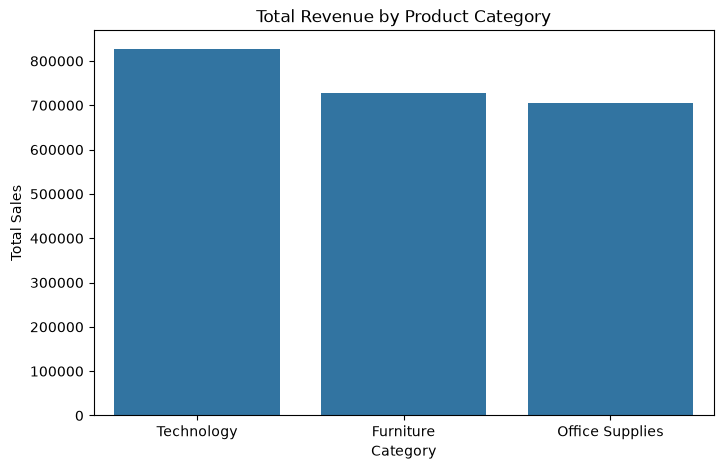

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

Which product category generates the highest total revenue? - Technology 

In [ ]:
region_year_sales = df.groupby(["Year", "Region"])["Sales"].sum().reset_index()
region_year_sales

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,153225.1830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,178511.5380


In [ ]:
region_year_pivot = region_year_sales.pivot(index="Year", columns="Region", values="Sales")  # sourced from internet 
region_year_pivot

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


So as we can see 
* East: Shows the most consistent upward trend, with sales increasing steadily across all four years and no visible decline.
* West: Shows strong overall growth and ends with the highest sales in the final year, but the trend is less consistent because of a dip in 2016 before rising again.
* Central: Remains relatively stable in the first two years, grows in 2017, and then slightly drops in 2018, so the trend is not consistently upward.
* South: sharp drop after 2015 followed by recovery in later years.

Which region has the most consistent sales growth over 4 years? - East 

In [ ]:
region_shipping = df.groupby("Region")["Shipping_Days"].mean().sort_values()
region_shipping

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping_Days, dtype: float64

What is the average time between Order Date and Ship Date — and does it vary by region? - Nope as u can see its almost uniform every region .. Average of about 4 days 

In [ ]:
monthly_pattern = df.groupby(["Year", "Month_Name"])["Sales"].sum().reset_index()

month_order = ["January", "February", "March", "April", "May", "June","July", "August", "September", "October", "November", "December"]

monthly_pattern["Month_Name"] = pd.Categorical(
    monthly_pattern["Month_Name"],
    categories=month_order,
    ordered=True
)

monthly_pattern = monthly_pattern.sort_values(["Year", "Month_Name"])
monthly_pattern.head(12)

,Year,Month_Name,Sales
4,2015,January,14205.7070
3,2015,February,4519.8920
7,2015,March,55205.7970
0,2015,April,27906.8550
8,2015,May,23644.3030
6,2015,June,34322.9356
5,2015,July,33781.5430
1,2015,August,27117.5365
11,2015,September,81623.5268
10,2015,October,31453.3930


In [ ]:
monthly_pivot = monthly_pattern.pivot(index="Month_Name", columns="Year", values="Sales")
monthly_pivot

Year,2015,2016,2017,2018
Month_Name,,,,
January,14205.7070,18066.9576,18542.4910,43476.4740
February,4519.8920,11951.4110,22978.8150,19920.9974
March,55205.7970,32339.3184,51165.0590,58863.4128
April,27906.8550,34154.4685,38679.7670,35541.9101
May,23644.3030,29959.5305,56656.9080,43825.9822
June,34322.9356,23599.3740,39724.4860,48190.7277
July,33781.5430,28608.2590,38320.7830,44825.1040
August,27117.5365,36818.3422,30542.2003,62837.8480
September,81623.5268,63133.6060,69193.3909,86152.8880


As we can see November and December shows the most consistent spikes across all years 

In [ ]:
daily_sales.to_csv("daily_sales.csv", index=False)
weekly_sales.to_csv("weekly_sales.csv", index=False)
monthly_sales.to_csv("monthly_sales.csv", index=False)

Task 1 Summary
* The dataset was cleaned and prepared for time-series analysis by converting date columns and generating temporal features such as year, month, week number, quarter, and season.
* Sales were aggregated at daily, weekly, and monthly levels to support downstream forecasting and anomaly detection tasks.
* Technology generated the highest total revenue among all product categories.
* The East region showed the most consistent sales growth over the four-year period.
* Shipping time varied slightly across regions, which may reflect regional logistics differences.
* Monthly sales patterns suggest seasonality, with November and December showing repeated sales spikes across years.

## Task 2


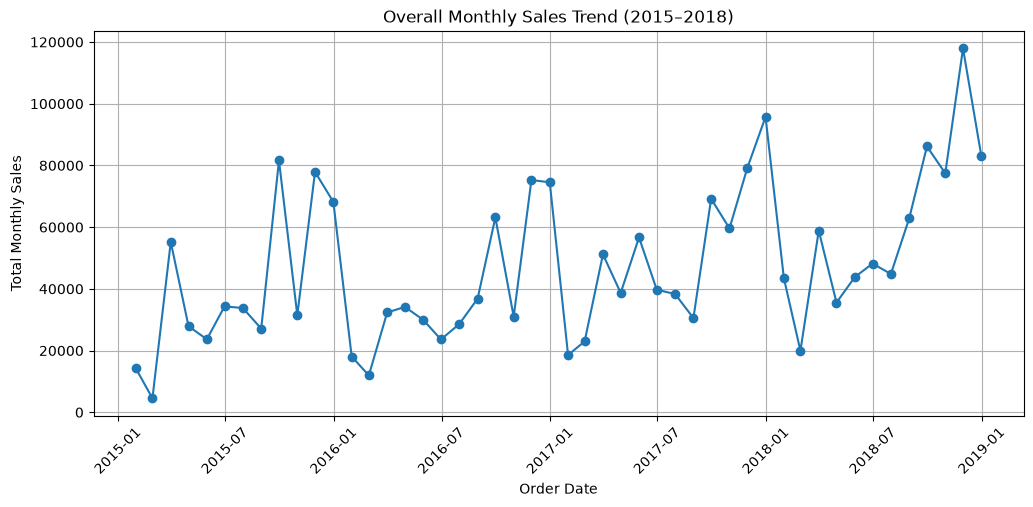

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller


plt.figure(figsize=(12,5))
plt.plot(monthly_sales["Order Date"], monthly_sales["Sales"], marker="o")
plt.title("Overall Monthly Sales Trend (2015–2018)")
plt.xlabel("Order Date")
plt.ylabel("Total Monthly Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Monthly sales patterns suggest seasonality, with several high-sales periods recurring across years. November and December often show strong sales, but the overall monthly trend also indicates that some major peaks occur around the beginning of the year in certain years. This suggests that seasonality exists, though the exact peak month is not perfectly uniform across all four years.

Time series Decomposition 

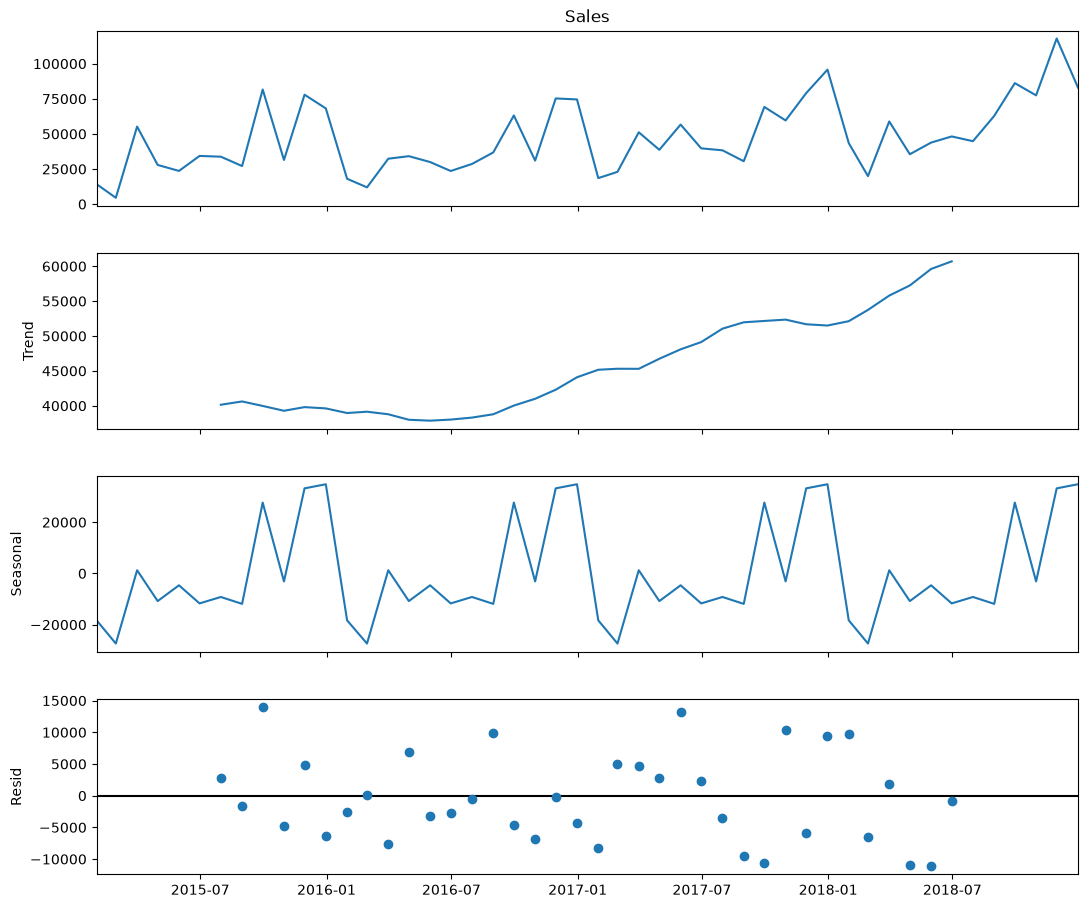

In [ ]:
monthly_ts = monthly_sales.set_index("Order Date")["Sales"]
decomposition = seasonal_decompose(monthly_ts, model="additive", period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.show()

Decomposition observations
* The trend component shows that overall sales increase over time, especially from mid-2016 onward, indicating long-term business growth.
* The seasonal component displays a repeating yearly pattern, suggesting that monthly sales are influenced by recurring seasonal effects rather      than being purely random.
* The observed sales series contains several sharp peaks and dips, but decomposition shows that part of this variation comes from underlying trend and seasonal structure.
* The residual component still contains noticeable fluctuations, meaning some months experience unusual sales behavior that cannot be fully explained by long-term growth and seasonality alone.

In [ ]:
residual_df = decomposition.resid.dropna().reset_index()
residual_df.columns = ["Order Date", "Residual"]

# Add absolute residual to find strongest noise months
residual_df["Abs_Residual"] = residual_df["Residual"].abs()

top_residual_months = residual_df.sort_values("Abs_Residual", ascending=False).head(5)
top_residual_months

#used ai help in this region 

,Order Date,Residual,Abs_Residual
2,2015-09-30,13970.933082,13970.933082
22,2017-05-31,13193.079793,13193.079793
34,2018-05-31,-11157.549320,11157.549320
33,2018-04-30,-10916.959724,10916.959724
26,2017-09-30,-10642.715643,10642.715643


From the decomposition residuals, the months with the strongest unexplained deviations are:

September 2015 → strongest positive residual noise
May 2017 → another strong positive residual spike
April 2018 and May 2018 → strong negative residual noise
September 2017 → another notable negative residual month

In [ ]:
adf_result = adfuller(monthly_ts)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of lags used:", adf_result[2])
print("Number of observations used:", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Number of lags used: 0
Number of observations used: 47

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


* Here p value is < 0.05 , thus we can infer it is stationary ... 
Stationary means the after considering factors like avg level and variance , the entity remains stable .. 

* The Augmented Dickey-Fuller (ADF) test was applied to the monthly sales series to check whether it is stationary. The test produced a p-value of 0.000278, which is lower than the significance threshold of 0.05. Therefore, the null hypothesis of non-stationarity is rejected. This suggests that the monthly sales series can be treated as stationary, so differencing was not required at this stage.

Differencing decision

Differencing is typically applied when a time series is non-stationary and needs to be stabilized before modeling.Since the ADF test indicated that the monthly sales series is already stationary, differencing was not applied. The original monthly series was retained for the forecasting tasks.

## Task 2 Summary
* The monthly sales series shows an overall upward trend, especially from the later part of the dataset, indicating long-term business growth.
* Time series decomposition reveals a clear seasonal pattern, suggesting that monthly sales are influenced by recurring yearly effects.
* Residual analysis shows that some months still experience unusually high or low sales even after removing trend and seasonality, indicating the presence of irregular noise.
* The ADF test was used to check stationarity, using a significance threshold of 0.05.
Since the p-value obtained (0.000278) is lower than 0.05, the monthly sales series was treated as stationary and differencing was not applied.

## TASK 3 - MODEL BUILDING

Downloaded models now imports 

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor

Already monthly sales and all done but not in memory

In [ ]:
monthly_sales = pd.read_csv("monthly_sales.csv")
monthly_sales['Order Date'] = pd.to_datetime(monthly_sales['Order Date'])

ts = monthly_sales.set_index('Order Date')['Sales']

train = ts.iloc[:-3]
test = ts.iloc[-3:]

print(train.tail())
print()
print(test)

Order Date
2018-05-31    43825.9822
2018-06-30    48190.7277
2018-07-31    44825.1040
2018-08-31    62837.8480
2018-09-30    86152.8880
Name: Sales, dtype: float64

Order Date
2018-10-31     77448.1312
2018-11-30    117938.1550
2018-12-31     83030.3888
Name: Sales, dtype: float64


Lets assign parameters now .. 
lets go with (1,0,1) (0,1,1,12) why ?-

* The ADF test showed that the monthly sales series is stationary, so d = 0.
* Since the data is aggregated monthly, a seasonal period of 12 was chosen to capture yearly seasonality.
* A seasonal differencing order of D = 1 was used to account for repeating yearly seasonal effects in the monthly sales pattern.
* p = 1 was chosen to allow the model to use the immediate previous month’s sales while keeping the model simple.
* q = 1 was used to account for short-term fluctuations and recent forecast errors in the series. 
* For the seasonal terms, P = 0 and Q = 1 were chosen to keep the seasonal structure simple while still capturing seasonal moving-average effects.

In [ ]:
sarima_model = SARIMAX(
    train,
    order=(1, 0, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()
print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 12)   Log Likelihood                -204.220
Date:                            Tue, 07 Jul 2026   AIC                            416.440
Time:                                    22:38:24   BIC                            420.218
Sample:                                01-31-2015   HQIC                           417.079
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9822      0.015     64.564      0.000       0.952       1.012
ma.L1         -0.9819      0.323   

Ok so now we got the values, lets just tune see if any better parameters 

In [ ]:
sarima_model = SARIMAX(
    train,
    order=(1, 0, 2),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()
print(sarima_result.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 2)x(0, 1, [1], 12)   Log Likelihood                -193.151
Date:                              Tue, 07 Jul 2026   AIC                            396.303
Time:                                      22:42:20   BIC                            400.755
Sample:                                  01-31-2015   HQIC                           396.917
                                       - 09-30-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5868      0.299      1.961      0.050       0.000       1.173
ma.L1          0.02

OK the aic is lesser so lets use this parameters 

In [ ]:
sarima_forecast_obj = sarima_result.get_forecast(steps=3)

sarima_forecast = sarima_forecast_obj.predicted_mean
sarima_ci = sarima_forecast_obj.conf_int()

print(sarima_forecast)
print()
print(sarima_ci)

2018-10-31    71451.928567
2018-11-30    86402.045714
2018-12-31    89172.716538
Freq: ME, Name: predicted_mean, dtype: float64

             lower Sales    upper Sales
2018-10-31  45342.758764   97561.098370
2018-11-30  55810.560804  116993.530625
2018-12-31  47023.943941  131321.489136


In [ ]:
sarima_mae = mean_absolute_error(test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
sarima_mape = np.mean(np.abs((test - sarima_forecast) / test)) * 100

print("MAE:", sarima_mae)
print("RMSE:", sarima_rmse)
print("MAPE:", sarima_mape)

MAE: 14558.213218860425
RMSE: 18869.806790534043
MAPE: 13.959811493218055


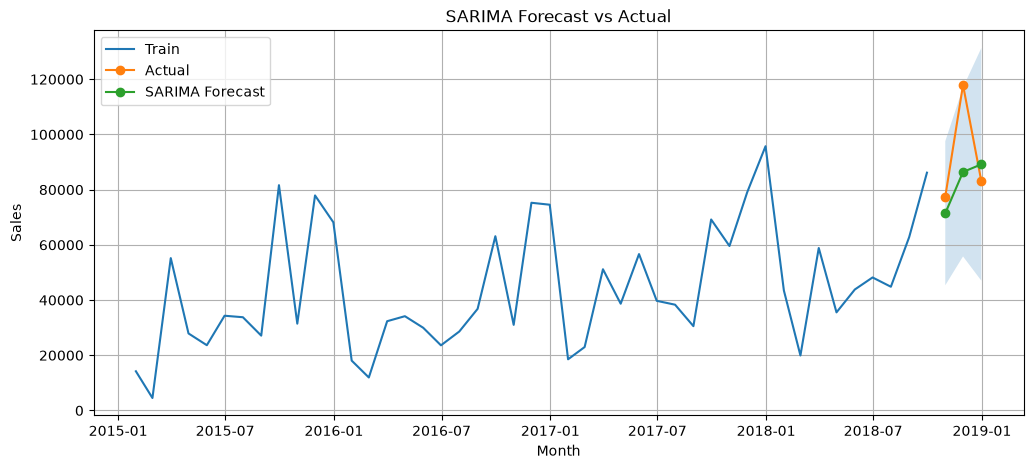

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual', marker='o')
plt.plot(sarima_forecast.index, sarima_forecast, label='SARIMA Forecast', marker='o')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], alpha=0.2)
plt.legend()
plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

Prediction of 2 months almost similar but has a big variation for November month ..  
Next Prophet .. 

In [ ]:
prophet_df = monthly_sales.copy()
prophet_df['Order Date'] = pd.to_datetime(prophet_df['Order Date'])
prophet_df = prophet_df.rename(columns={'Order Date': 'ds', 'Sales': 'y'})

prophet_train = prophet_df.iloc[:-3]
prophet_test = prophet_df.iloc[-3:]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)

23:18:12 - cmdstanpy - INFO - Chain [1] start processing
23:18:13 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
future = prophet_model.make_future_dataframe(periods=3, freq='ME')
prophet_forecast_full = prophet_model.predict(future)

prophet_forecast_full[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6)

,ds,yhat,yhat_lower,yhat_upper
42,2018-07-31,45426.641996,37130.159271,53975.688770
43,2018-08-31,47271.558211,39182.332971,55253.429058
44,2018-09-30,86613.953290,78689.090246,94960.919745
45,2018-10-31,51318.943831,43076.329536,59101.968809
46,2018-11-30,90325.654756,82742.637975,98392.097405
47,2018-12-31,90041.084451,82031.220681,98381.868063


In [ ]:
prophet_pred = prophet_forecast_full[['ds', 'yhat']].tail(3).copy()
prophet_pred = prophet_pred.set_index('ds')['yhat']

prophet_compare = pd.DataFrame({
    'Actual': test,
    'Predicted': prophet_pred
})

prophet_compare

,Actual,Predicted
2018-10-31,77448.1312,51318.943831
2018-11-30,117938.1550,90325.654756
2018-12-31,83030.3888,90041.084451


Big difference 

In [ ]:
prophet_mae = mean_absolute_error(prophet_compare['Actual'], prophet_compare['Predicted'])
prophet_rmse = np.sqrt(mean_squared_error(prophet_compare['Actual'], prophet_compare['Predicted']))
prophet_mape = np.mean(np.abs((prophet_compare['Actual'] - prophet_compare['Predicted']) / prophet_compare['Actual'])) * 100

print("MAE:", prophet_mae)
print("RMSE:", prophet_rmse)
print("MAPE:", prophet_mape)

MAE: 20250.794421218907
RMSE: 22318.41135158084
MAPE: 21.86462828185426


Lets tune a bit .. this feels a bit off ( used help of ai for this)

In [ ]:
prophet_results = []

configs = [
    {'changepoint_prior_scale': 0.05, 'seasonality_mode': 'additive'},
    {'changepoint_prior_scale': 0.1, 'seasonality_mode': 'additive'},
    {'changepoint_prior_scale': 0.05, 'seasonality_mode': 'multiplicative'},
    {'changepoint_prior_scale': 0.1, 'seasonality_mode': 'multiplicative'}
]

for config in configs:
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=config['changepoint_prior_scale'],
        seasonality_mode=config['seasonality_mode']
    )

    model.fit(prophet_train)

    future = model.make_future_dataframe(periods=3, freq='ME')
    forecast = model.predict(future)

    pred = forecast[['ds', 'yhat']].tail(3).set_index('ds')['yhat']

    actual = prophet_test.set_index('ds')['y']

    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100

    prophet_results.append([
        config['changepoint_prior_scale'],
        config['seasonality_mode'],
        mae,
        rmse,
        mape
    ])

prophet_tuning = pd.DataFrame(
    prophet_results,
    columns=['changepoint_prior_scale', 'seasonality_mode', 'MAE', 'RMSE', 'MAPE']
)

prophet_tuning.sort_values('RMSE')

23:22:55 - cmdstanpy - INFO - Chain [1] start processing
23:22:56 - cmdstanpy - INFO - Chain [1] done processing
23:22:56 - cmdstanpy - INFO - Chain [1] start processing
23:22:56 - cmdstanpy - INFO - Chain [1] done processing
23:22:56 - cmdstanpy - INFO - Chain [1] start processing
23:22:56 - cmdstanpy - INFO - Chain [1] done processing
23:22:56 - cmdstanpy - INFO - Chain [1] start processing
23:22:57 - cmdstanpy - INFO - Chain [1] done processing


,changepoint_prior_scale,seasonality_mode,MAE,RMSE,MAPE
1,0.10,additive,19443.956105,20513.808911,21.159830
3,0.10,multiplicative,21074.768775,21609.124663,24.036035
0,0.05,additive,20250.794421,22318.411352,21.864628
2,0.05,multiplicative,21644.827520,22533.761189,24.423421


Even after tuning , not much of a change .. 

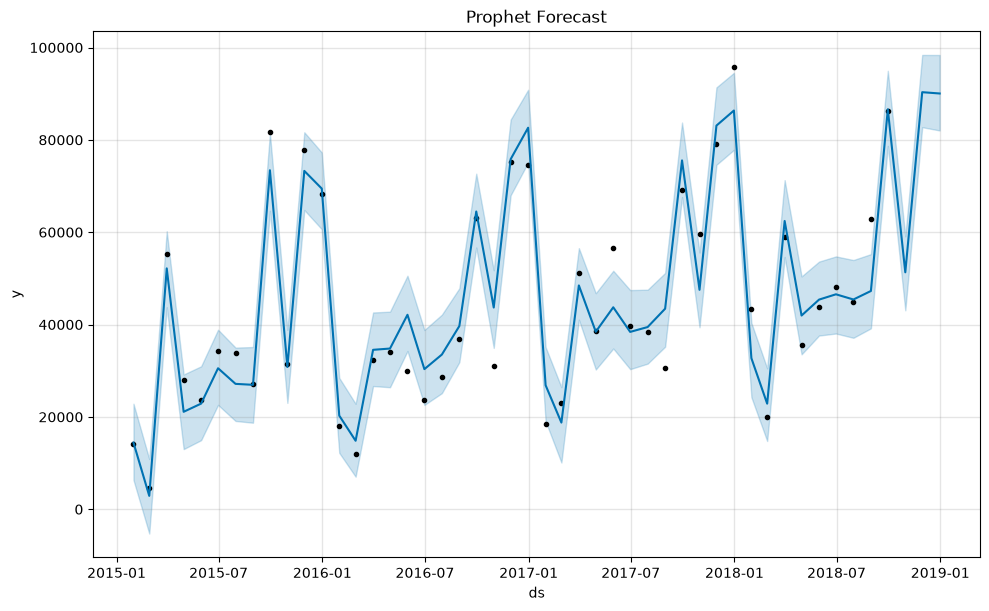

In [ ]:
fig1 = prophet_model.plot(prophet_forecast_full)
plt.title("Prophet Forecast")
plt.show()

The Prophet model was trained on the monthly sales series using yearly seasonality. The forecast plot shows the fitted historical trend and the projected sales for the next 3 months. The component breakdown shows the overall trend and the yearly seasonal effect learned by the model.

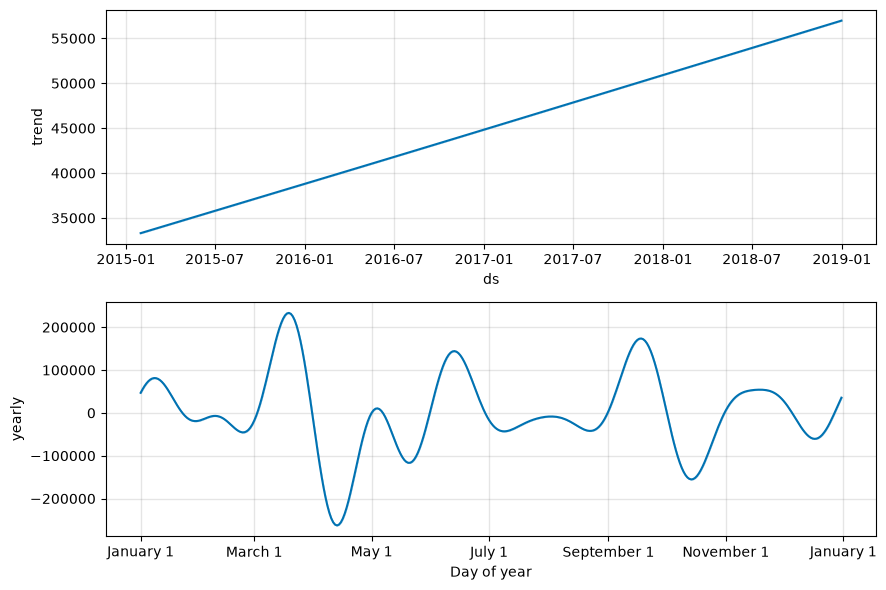

In [ ]:
fig2 = prophet_model.plot_components(prophet_forecast_full)
plt.show()

In [ ]:
prophet_forecast_full[['ds', 'trend', 'yearly']].tail(12)

,ds,trend,yearly
36,2018-01-31,51413.676362,-18694.988501
37,2018-02-28,51879.718059,-29010.557362
38,2018-03-31,52395.692795,10035.116562
39,2018-04-30,52895.023184,-10941.655539
40,2018-05-31,53410.997920,-8009.958347
41,2018-06-30,53910.328309,-7356.667100
42,2018-07-31,54426.303045,-8999.661049
43,2018-08-31,54942.277781,-7670.719569
44,2018-09-30,55441.608170,31172.345120
45,2018-10-31,55957.582906,-4638.639074


Yearly seasonality interpretation:
The yearly seasonality plot shows recurring month-of-year effects in the sales data. Positive seasonal values indicate periods where sales tend to be above the baseline trend, while negative values indicate periods where sales tend to fall below trend. In this dataset, Prophet identifies strong positive seasonal peaks around March, June, and September, and negative dips around April and October, suggesting repeating seasonal fluctuations in monthly sales.

Weekly seasonality: Weekly seasonality was not modeled because the sales data was aggregated at the monthly level. As a result, weekly patterns are not preserved in the dataset and would not provide meaningful information for forecasting.

lets go xgboost 

In [ ]:
xgb_df = monthly_sales.copy()
xgb_df['Order Date'] = pd.to_datetime(xgb_df['Order Date'])

xgb_df['lag_1'] = xgb_df['Sales'].shift(1)
xgb_df['lag_2'] = xgb_df['Sales'].shift(2)
xgb_df['lag_3'] = xgb_df['Sales'].shift(3)

xgb_df['rolling_mean_3'] = xgb_df['Sales'].shift(1).rolling(3).mean()

xgb_df['month'] = xgb_df['Order Date'].dt.month
xgb_df['quarter'] = xgb_df['Order Date'].dt.quarter

def get_season(m):
    if m in [12, 1, 2]:
        return 1
    elif m in [3, 4, 5]:
        return 2
    elif m in [6, 7, 8]:
        return 3
    else:
        return 4

xgb_df['season'] = xgb_df['month'].apply(get_season)

xgb_df = xgb_df.dropna().reset_index(drop=True)
xgb_df.head()

,Order Date,Sales,lag_1,lag_2,lag_3,rolling_mean_3,month,quarter,season
0,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,24643.798667,4,2,2
1,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,29210.848000,5,2,2
2,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,35585.651667,6,2,3
3,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,28624.697867,7,3,3
4,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,30582.927200,8,3,3


In [ ]:
feature_cols = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'month', 'quarter', 'season']

train_xgb = xgb_df.iloc[:-3]
test_xgb = xgb_df.iloc[-3:]

X_train = train_xgb[feature_cols]
y_train = train_xgb['Sales']

X_test = test_xgb[feature_cols]
y_test = test_xgb['Sales']

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = np.mean(np.abs((y_test - xgb_pred) / y_test)) * 100

print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("MAPE:", xgb_mape)

xgb_compare = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': xgb_pred
}, index=test_xgb['Order Date'])

xgb_compare

MAE: 18710.454166666666
RMSE: 20852.56792703449
MAPE: 19.119505203656935


,Actual,Predicted
Order Date,,
2018-10-31,77448.1312,68952.867188
2018-11-30,117938.1550,87130.101562
2018-12-31,83030.3888,66202.343750


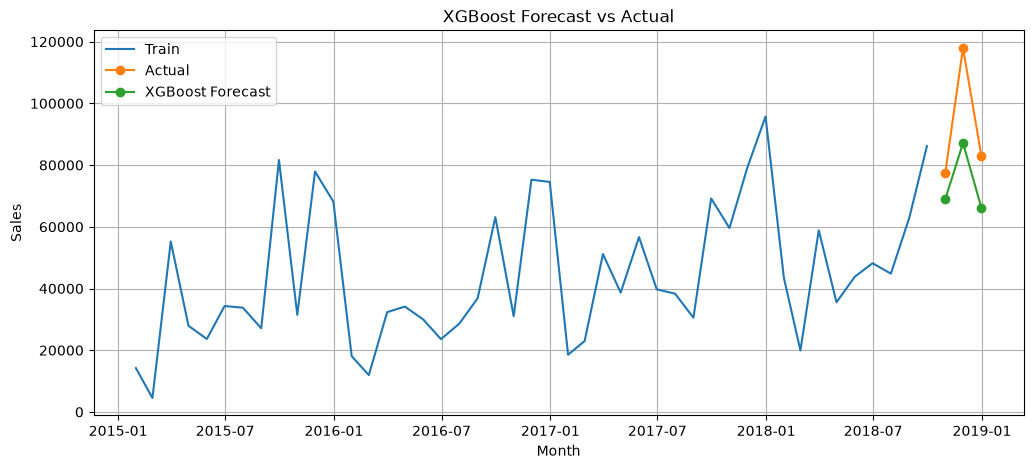

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual', marker='o')
plt.plot(test_xgb['Order Date'], xgb_pred, label='XGBoost Forecast', marker='o')
plt.title("XGBoost Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

Uhm this prediction also far off .. 

In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [14558.21, 20250.79, 18710.45],
    'RMSE': [18869.81, 22318.41, 20852.57],
    'MAPE': [13.96, 21.86, 19.12],
    'Forecast for Month 1': [71451.93, 52134.86, 68952.87],
    'Forecast for Month 2': [86402.05, 92589.16, 87130.10],
    'Forecast for Month 3': [89172.72, 92740.63, 66202.34]
})

comparison_df

,Model,MAE,RMSE,MAPE,Forecast for Month 1,Forecast for Month 2,Forecast for Month 3
0,SARIMA,14558.21,18869.81,13.96,71451.93,86402.05,89172.72
1,Prophet,20250.79,22318.41,21.86,52134.86,92589.16,92740.63
2,XGBoost,18710.45,20852.57,19.12,68952.87,87130.10,66202.34


## Recommended Model for Production

Based on the model comparison results, SARIMA is recommended for production use.


* SARIMA has the lowest MAE (14558.21),lowest RMSE (18869.81),lowest MAPE (13.96%)

Since SARIMA performs best across all evaluation metrics, it is the most accurate and reliable model for forecasting monthly sales in this dataset.

### Conclusion:
Therefore,SARIMA is the best choice for production deployment for this sales forecasting task.

## Task 4

In [23]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [ ]:
furniture_df = df[df['Category'] == 'Furniture']
technology_df = df[df['Category'] == 'Technology']
office_df = df[df['Category'] == 'Office Supplies']

west_df = df[df['Region'] == 'West']
east_df = df[df['Region'] == 'East']

furniture_monthly = furniture_df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()
technology_monthly = technology_df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()
office_monthly = office_df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()

west_monthly = west_df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()
east_monthly = east_df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()

In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

furniture_model = SARIMAX(furniture_monthly, order=(1,0,2), seasonal_order=(1,1,1,12))
furniture_result = furniture_model.fit(disp=False)
furniture_forecast = furniture_result.forecast(steps=3)

technology_model = SARIMAX(technology_monthly, order=(1,0,2), seasonal_order=(1,1,1,12))
technology_result = technology_model.fit(disp=False)
technology_forecast = technology_result.forecast(steps=3)

office_model = SARIMAX(office_monthly, order=(1,0,2), seasonal_order=(1,1,1,12))
office_result = office_model.fit(disp=False)
office_forecast = office_result.forecast(steps=3)

west_model = SARIMAX(west_monthly, order=(1,0,2), seasonal_order=(1,1,1,12))
west_result = west_model.fit(disp=False)
west_forecast = west_result.forecast(steps=3)

east_model = SARIMAX(east_monthly, order=(1,0,2), seasonal_order=(1,1,1,12))
east_result = east_model.fit(disp=False)
east_forecast = east_result.forecast(steps=3)

C:\Users\Vighnesh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\Vighnesh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Vighnesh\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Vighnesh\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed 

In [26]:
print("Furniture Forecast")
print(furniture_forecast)

print("\nTechnology Forecast")
print(technology_forecast)

print("\nOffice Supplies Forecast")
print(office_forecast)

print("\nWest Region Forecast")
print(west_forecast)

print("\nEast Region Forecast")
print(east_forecast)

Furniture Forecast
2019-01-31     5325.194801
2019-02-28     6361.412481
2019-03-31    12257.796735
Freq: ME, Name: predicted_mean, dtype: float64

Technology Forecast
2019-01-31    18778.758213
2019-02-28    15467.611492
2019-03-31    32348.171699
Freq: ME, Name: predicted_mean, dtype: float64

Office Supplies Forecast
2019-01-31    17503.654464
2019-02-28    12217.196067
2019-03-31    20770.420012
Freq: ME, Name: predicted_mean, dtype: float64

West Region Forecast
2019-01-31    14437.206531
2019-02-28    12173.505545
2019-03-31    27996.605750
Freq: ME, Name: predicted_mean, dtype: float64

East Region Forecast
2019-01-31    4863.574307
2019-02-28   -2264.287259
2019-03-31    9713.898813
Freq: ME, Name: predicted_mean, dtype: float64


In [27]:
task4_forecast_df = pd.DataFrame({
    'Furniture': furniture_forecast.values,
    'Technology': technology_forecast.values,
    'Office Supplies': office_forecast.values,
    'West': west_forecast.values,
    'East': east_forecast.values
}, index=furniture_forecast.index)

task4_forecast_df

,Furniture,Technology,Office Supplies,West,East
2019-01-31,5325.194801,18778.758213,17503.654464,14437.206531,4863.574307
2019-02-28,6361.412481,15467.611492,12217.196067,12173.505545,-2264.287259
2019-03-31,12257.796735,32348.171699,20770.420012,27996.605750,9713.898813


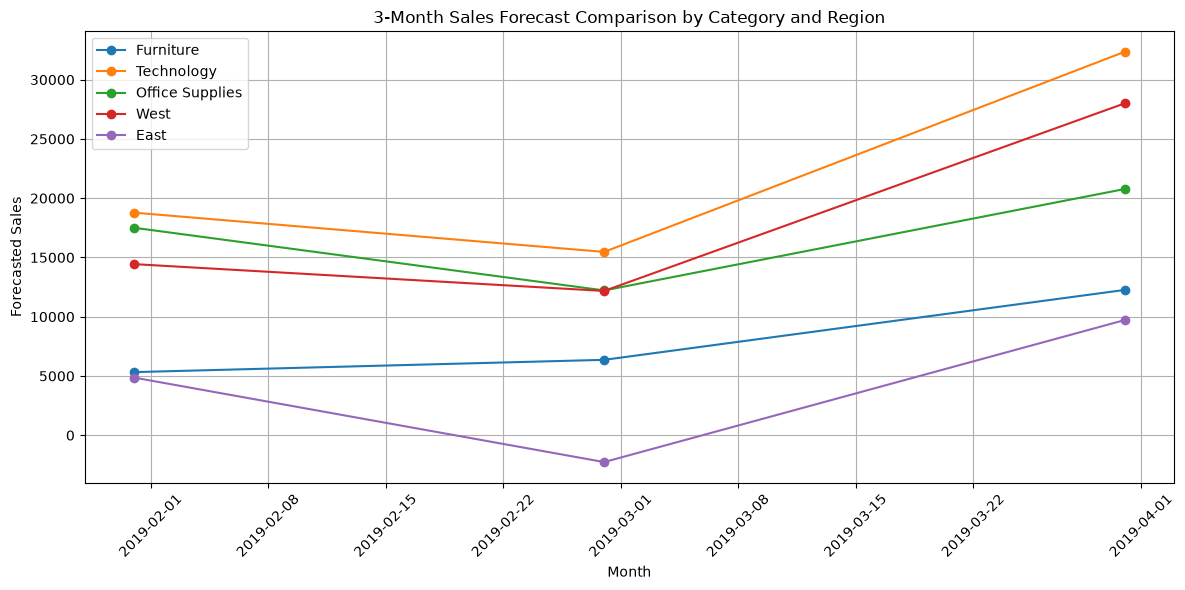

In [28]:
plt.figure(figsize=(12,6))

plt.plot(task4_forecast_df.index, task4_forecast_df['Furniture'], marker='o', label='Furniture')
plt.plot(task4_forecast_df.index, task4_forecast_df['Technology'], marker='o', label='Technology')
plt.plot(task4_forecast_df.index, task4_forecast_df['Office Supplies'], marker='o', label='Office Supplies')
plt.plot(task4_forecast_df.index, task4_forecast_df['West'], marker='o', label='West')
plt.plot(task4_forecast_df.index, task4_forecast_df['East'], marker='o', label='East')

plt.title('3-Month Sales Forecast Comparison by Category and Region')
plt.xlabel('Month')
plt.ylabel('Forecasted Sales')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 4 Conclusion

Based on the SARIMA forecast results for the next three months, the Technology category is showing the strongest upcoming growth.

### Reason:
- Technology has the highest forecasted sales values overall, especially in **March 2019 (32348.17).
- It performs better than Furniture, Office Supplies, West, and East in terms of projected sales magnitude.
- Although the West region also shows strong growth, its March forecast (27996.61) is still lower than Technology.

### Conclusion:
Therefore, according to the model, the Technology category is expected to show the strongest upcoming growth among the selected product categories and regions.